In [1]:
import torch
import random
import numpy as np
import torch.nn as nn
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.datasets import make_blobs
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed = 42
seed_everything(seed)

In [4]:
def choose_device():
    dev_str = ""
    device = None
    if torch.cuda.is_available():
        device = torch.device("cuda")
        dev_str = f"Using CUDA: {torch.cuda.get_device_name(0)}"
    elif torch.backends.mps.is_available() and torch.backends.mps.is_built():
        device = torch.device("mps")
        dev_str = "Using Apple Metal Performance Shaders (MPS)"
    else:
        device = torch.device("cpu")
        dev_str = "Using CPU"
    return device, dev_str


device, device_str = choose_device()
print(device_str)

Using Apple Metal Performance Shaders (MPS)


In [5]:
mpl.rcParams.update({
    "figure.figsize": (6, 5),
    "figure.dpi": 300,        
    "savefig.dpi": 400,       
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.linewidth": 1.2,
    "lines.linewidth": 2.0,
})

Train size: 2100 Test size: 900
Class balance (train): [700 700 700]


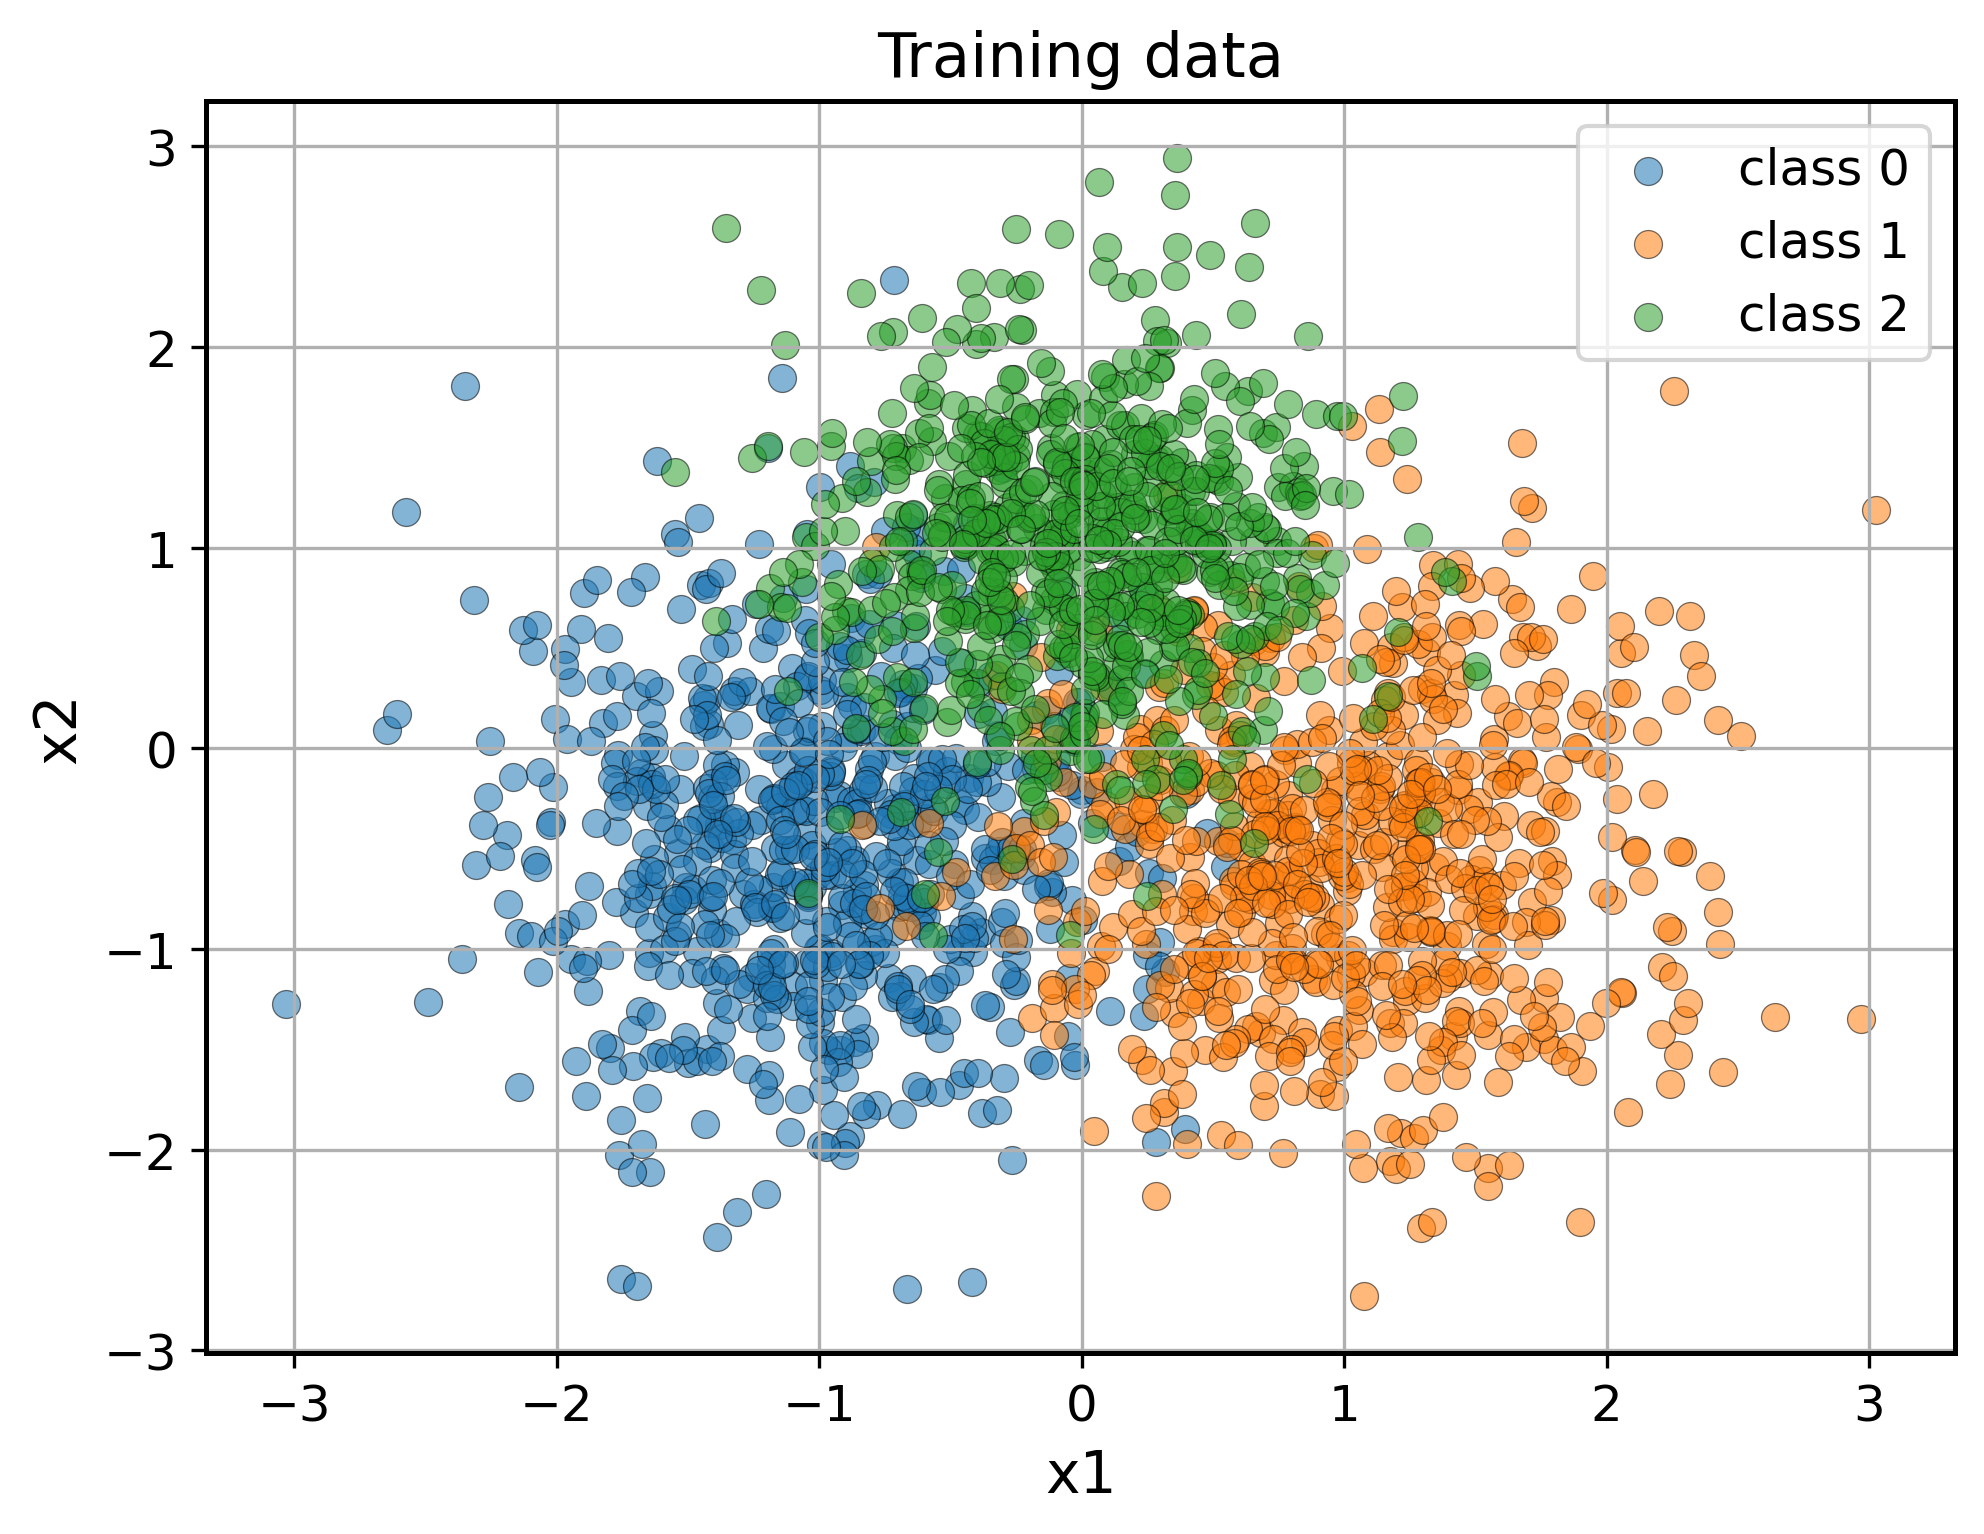

In [6]:
centers = np.array([(-2.0, 0.0), (2.0, 0.0), (0.0, 2.5)], dtype=float)

blobs = make_blobs(
    n_samples=3000,
    centers=centers,
    cluster_std=[1.2, 1.2, 1.0],
    random_state=seed,
    return_centers=False,
)
X = blobs[0]
y = blobs[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=seed
)

scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
y_train_t = torch.tensor(y_train, dtype=torch.long, device=device)
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)
y_test_t = torch.tensor(y_test, dtype=torch.long, device=device)

print('Train size:', len(X_train), 'Test size:', len(X_test))
print('Class balance (train):', np.bincount(y_train))

# fig, ax = plt.subplots()
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)
for cls in np.unique(y_train):
    idx = y_train == cls
    ax.scatter(X_train[idx, 0],
               X_train[idx, 1],
               #    s=14,
               s=45,
               edgecolors="k",
               linewidths=0.3,
               alpha=0.55,
               label=f'class {cls}')
ax.set_title('Training data')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.legend(loc='best')
plt.show()

In [7]:
class SmallMLP(nn.Module):
    def __init__(self, out_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def custom_loss(model_output: torch.Tensor, targets: torch.Tensor, reward: float = 2.0) -> torch.Tensor:
    probs = torch.softmax(model_output, dim=1)
    class_probs = probs[:, :-1]
    reservation = probs[:, -1]
    gain = torch.gather(class_probs, dim=1,
                        index=targets.unsqueeze(1)).squeeze(1)
    stable = gain + reservation / reward + 1e-8
    return -torch.log(stable).mean()


def train_model(model, loss_fn, X_train, y_train, epochs=150, lr=5e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        opt.zero_grad()
        logits = model(X_train)
        loss = loss_fn(logits, y_train)
        loss.backward()
        opt.step()
    return model


def evaluate_ce(model):
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1)
        acc = (pred == y_test_t).float().mean().item()
        err = 1.0 - acc
        return {
            'accuracy': acc,
            'error': err,
            'pred': pred.cpu().numpy(),
            'probs': probs.cpu().numpy(),
        }


def evaluate_rejection(model, threshold=None):
    with torch.no_grad():
        logits = model(X_test_t)
        probs = torch.softmax(logits, dim=1)
        class_probs = probs[:, :-1]
        reservation = probs[:, -1]
        pred = class_probs.argmax(dim=1)

        if threshold is None:
            accepted = reservation < class_probs.max(dim=1).values
        else:
            accepted = reservation < threshold

        coverage = accepted.float().mean().item()
        accepted_count = max(accepted.float().sum().item(), 1.0)
        accepted_acc = ((pred == y_test_t) & accepted).float(
        ).sum().item() / accepted_count
        accepted_err = 1.0 - accepted_acc
        overall_acc = (pred == y_test_t).float().mean().item()

        return {
            'overall_accuracy': overall_acc,
            'coverage': coverage,
            'accepted_accuracy': accepted_acc,
            'accepted_error': accepted_err,
            'pred': pred.cpu().numpy(),
            'accepted': accepted.cpu().numpy(),
            'reservation': reservation.cpu().numpy(),
            'y_true': y_test_t.cpu().numpy(),
            'probs': probs.cpu().numpy(),
        }

Cross-entropy test accuracy: 0.886
Cross-entropy test error:    0.114


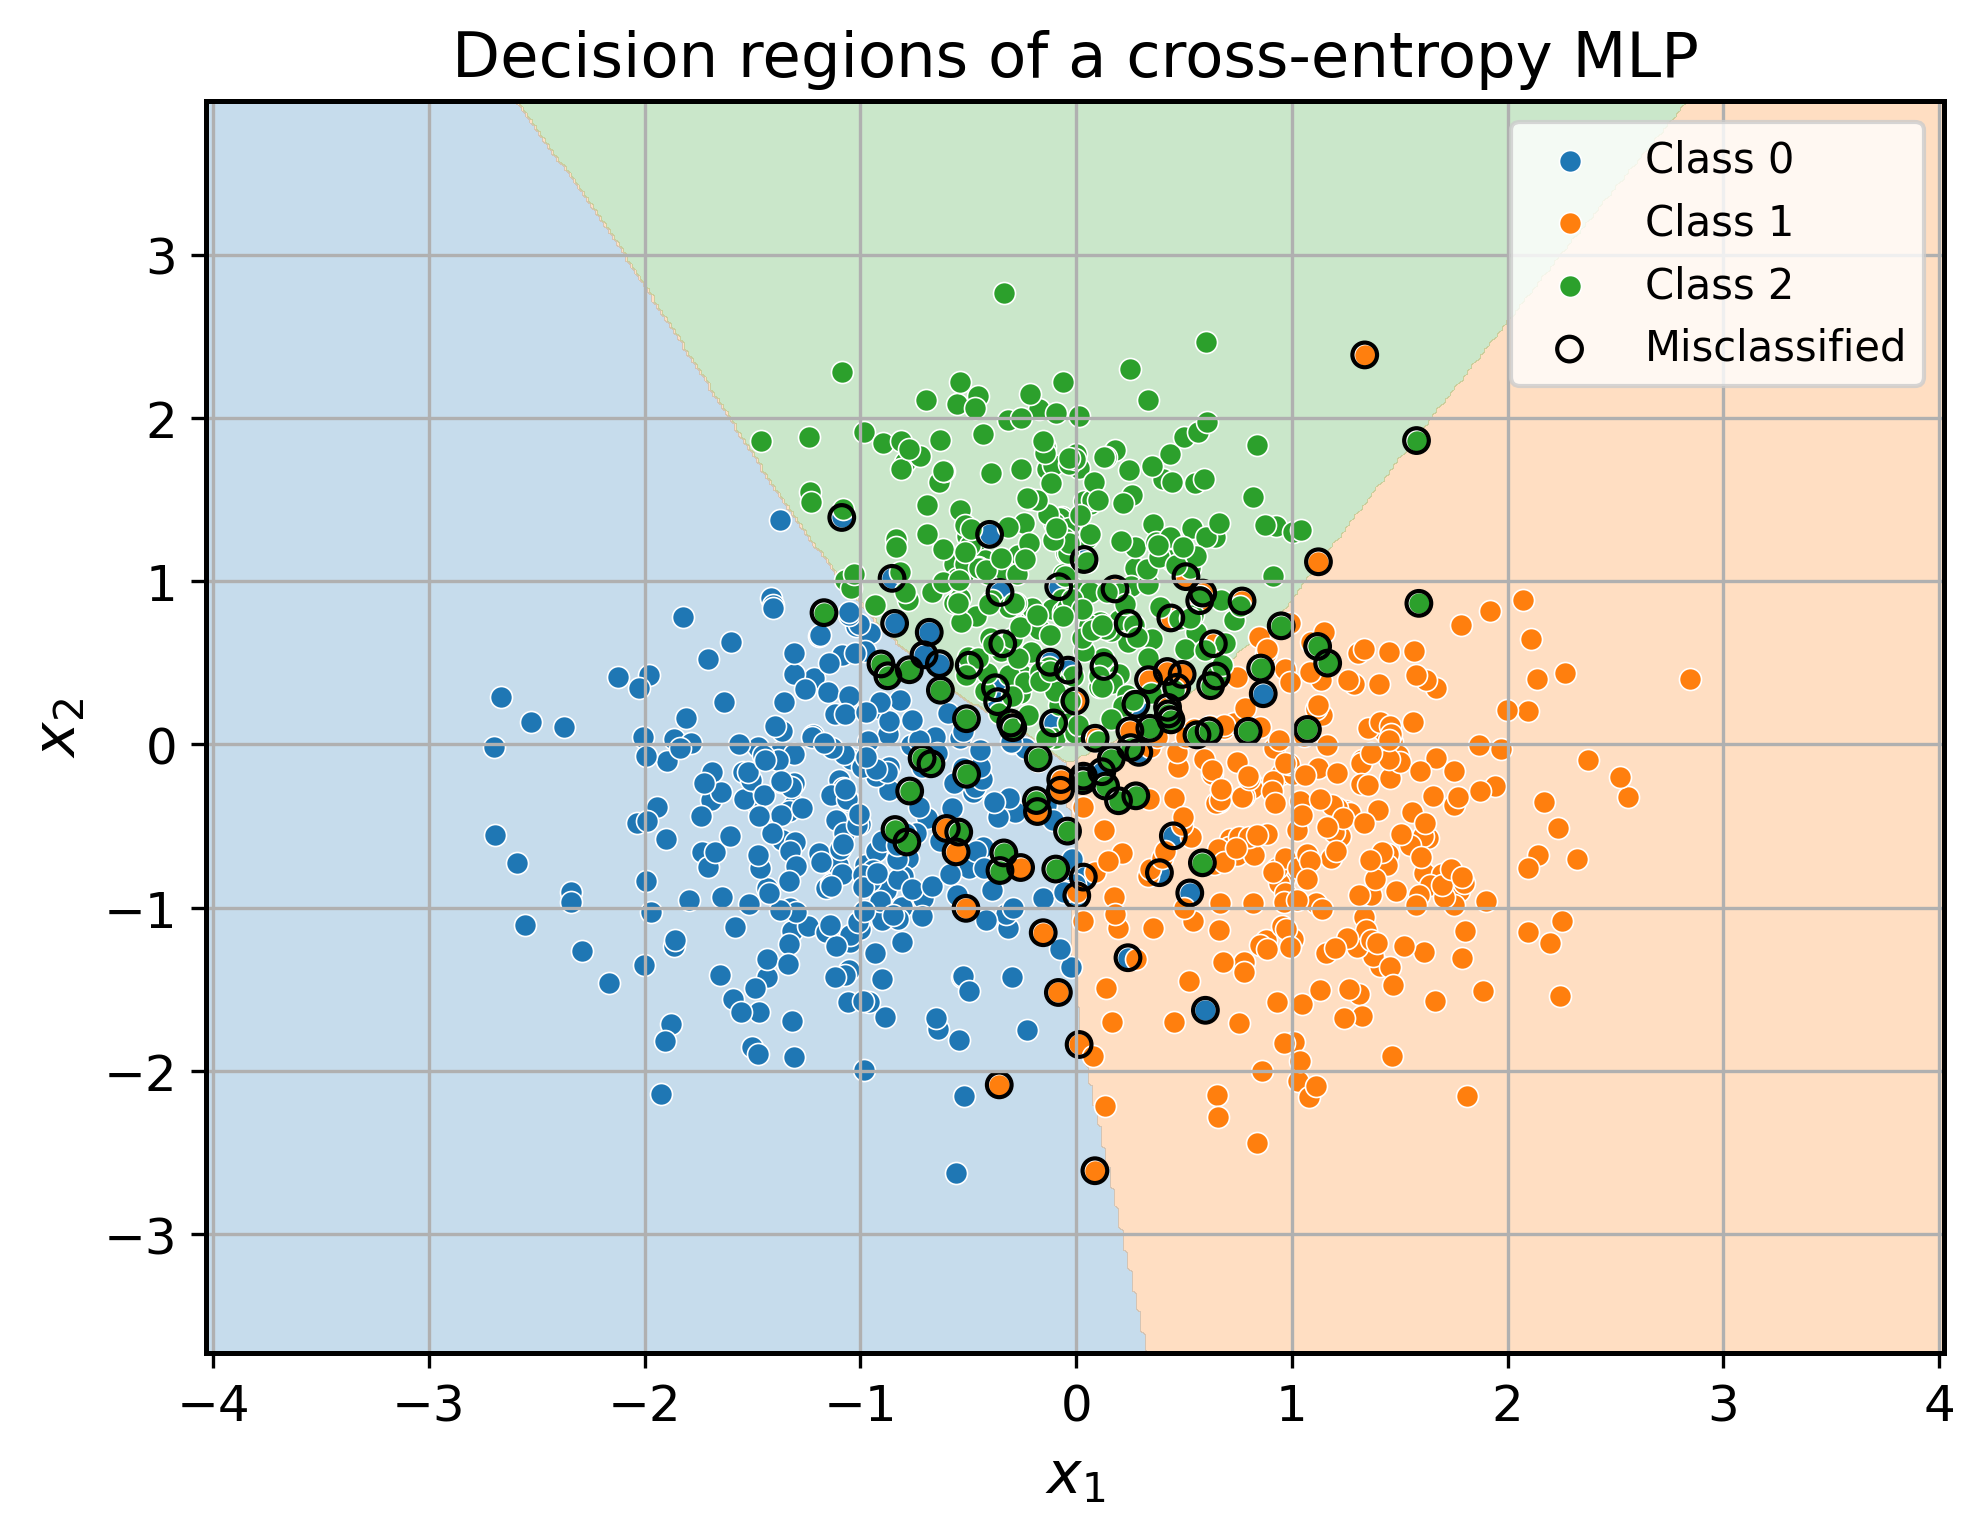

In [8]:
# CE model

# -------------------------------------------------------------
# Train cross-entropy model
# -------------------------------------------------------------
ce_model = SmallMLP(out_dim=3)
ce_model = train_model(
    ce_model,
    loss_fn=lambda logits, targets: F.cross_entropy(logits, targets),
    X_train=X_train_t,
    y_train=y_train_t,
    epochs=120,
    lr=5e-3,
)

ce_metrics = evaluate_ce(ce_model)

print(f"Cross-entropy test accuracy: {ce_metrics['accuracy']:.3f}")
print(f"Cross-entropy test error:    {ce_metrics['error']:.3f}")

# -------------------------------------------------------------
# Plot decision regions
# -------------------------------------------------------------
# Use sampled RGBA values from the colormap (type-checker friendly)
colors = mpl.colormaps["tab10"](np.arange(3))
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

x_min, x_max = X_train[:, 0].min() - 1.0, X_train[:, 0].max() + 1.0
y_min, y_max = X_train[:, 1].min() - 1.0, X_train[:, 1].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 400),
    np.linspace(y_min, y_max, 400),
)

grid = np.c_[xx.ravel(), yy.ravel()]

with torch.no_grad():
    grid_t = torch.tensor(grid, dtype=torch.float32, device=device)
    pred = (
        torch.softmax(ce_model(grid_t), dim=1)
        .argmax(dim=1)
        .cpu()
        .numpy()
    )

# Decision regions
ax.contourf(
    xx,
    yy,
    pred.reshape(xx.shape),
    levels=np.arange(4) - 0.5,
    cmap=cmap,
    alpha=0.25,
)

# Test samples (one scatter per class so the legend is correct)
for cls in np.unique(y_test):
    idx = y_test == cls
    ax.scatter(
        X_test[idx, 0],
        X_test[idx, 1],
        color=colors[cls],
        s=28,
        edgecolors="white",
        linewidths=0.4,
        label=f"Class {cls}",
    )

# Highlight misclassified samples
mistakes = ce_metrics["pred"] != y_test

ax.scatter(
    X_test[mistakes, 0],
    X_test[mistakes, 1],
    s=35,
    facecolors="none",
    edgecolors="black",
    linewidths=1.0,
    label="Misclassified",
)

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Decision regions of a cross-entropy MLP")

ax.legend(frameon=True, fontsize=10)

plt.show()

Rejection model coverage:        0.810
Accuracy on accepted samples:    0.944
Error on accepted samples:       0.056


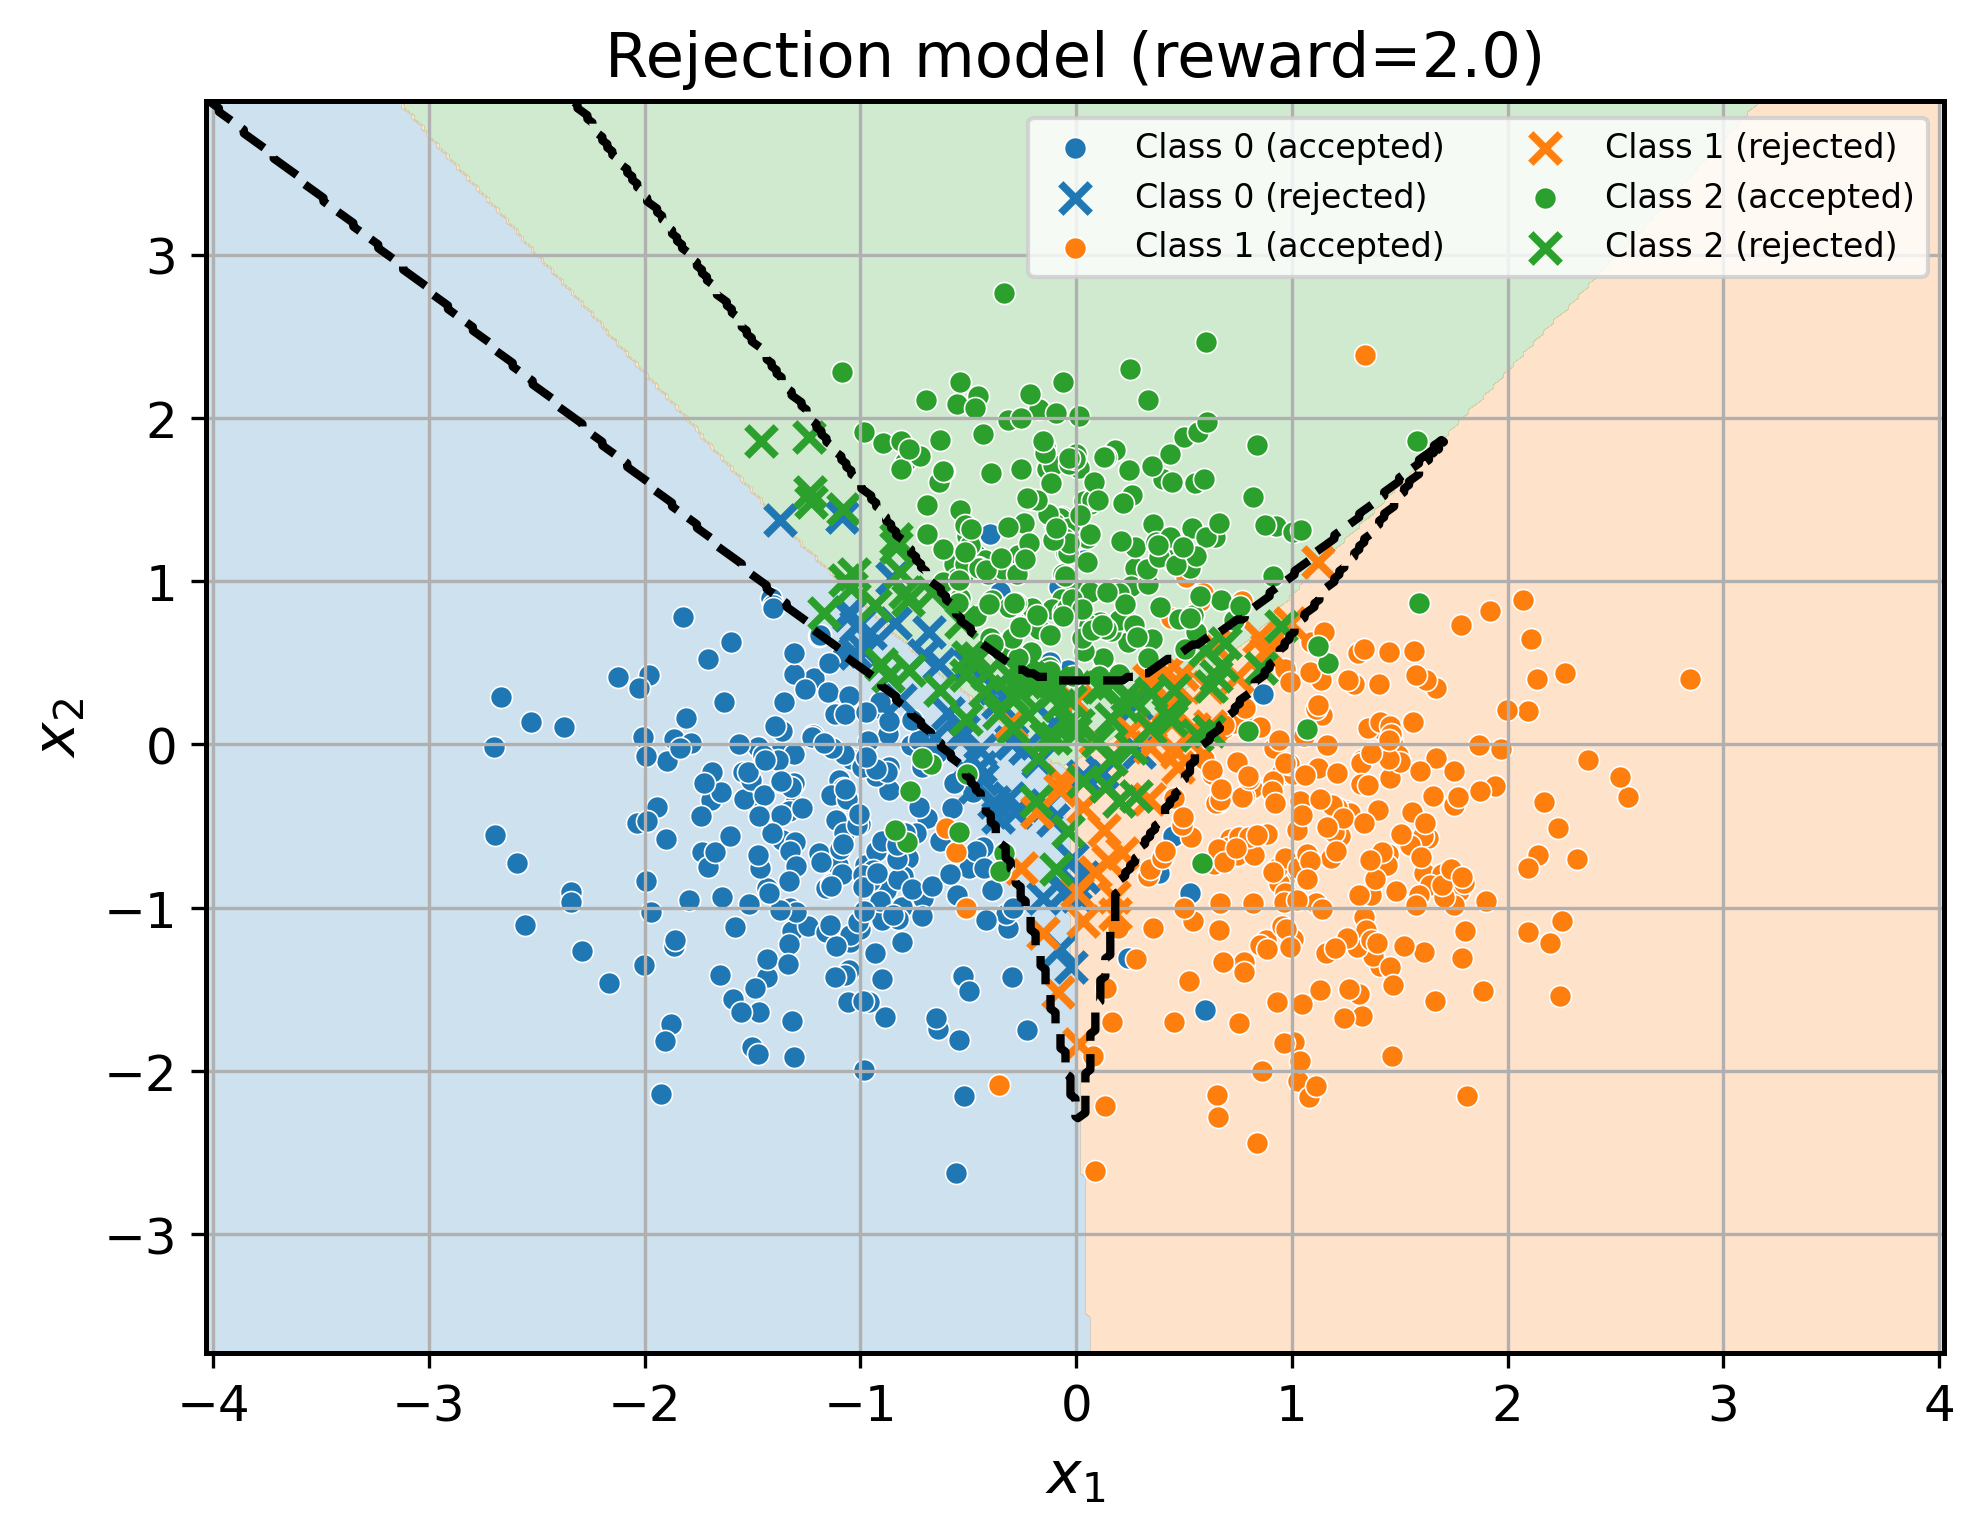

In [9]:
# Train rejection model
reward = 2.
rej_model = SmallMLP(out_dim=4)
rej_model = train_model(
    rej_model,
    loss_fn=lambda logits, targets: custom_loss(
        logits, targets, reward=reward),
    X_train=X_train_t,
    y_train=y_train_t,
    epochs=150,
    lr=5e-3,
)

rej_metrics_default = evaluate_rejection(rej_model, threshold=None)
print(
    f"Rejection model coverage:        {rej_metrics_default['coverage']:.3f}")
print(
    f"Accuracy on accepted samples:    {rej_metrics_default['accepted_accuracy']:.3f}")
print(
    f"Error on accepted samples:       {rej_metrics_default['accepted_error']:.3f}")

# -------------------------------------------------------------
# Plot decision regions + accepted/rejected samples
# -------------------------------------------------------------
colors = plt.get_cmap("tab10")(np.arange(3))
cmap = ListedColormap(colors)

fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)

x_min, x_max = X_train[:, 0].min() - 1.0, X_train[:, 0].max() + 1.0
y_min, y_max = X_train[:, 1].min() - 1.0, X_train[:, 1].max() + 1.0

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 350),
    np.linspace(y_min, y_max, 350),
)
grid = np.c_[xx.ravel(), yy.ravel()]

with torch.no_grad():
    grid_t = torch.tensor(grid, dtype=torch.float32, device=device)
    probs = torch.softmax(rej_model(grid_t), dim=1)
    class_probs = probs[:, :-1]
    reservation = probs[:, -1]

    labels = class_probs.argmax(dim=1).cpu().numpy()
    abstain = (reservation >= class_probs.max(dim=1).values).cpu().numpy()

# Background class regions
ax.contourf(
    xx,
    yy,
    labels.reshape(xx.shape),
    levels=np.arange(4) - 0.5,
    cmap=cmap,
    alpha=0.22,
)

# Reject region shown as dashed contour
ax.contour(
    xx,
    yy,
    abstain.reshape(xx.shape),
    levels=[0.5],
    colors="black",
    linewidths=2.0,
    linestyles="--",
)

accepted = rej_metrics_default["accepted"]

# Accepted and rejected points, colored by true class
for cls in np.unique(y_test):
    cls = int(cls)

    acc_idx = (y_test == cls) & accepted
    rej_idx = (y_test == cls) & (~accepted)

    ax.scatter(
        X_test[acc_idx, 0],
        X_test[acc_idx, 1],
        s=28,
        color=colors[cls],
        edgecolors="white",
        linewidths=0.4,
        label=f"Class {cls} (accepted)",
    )

    ax.scatter(
        X_test[rej_idx, 0],
        X_test[rej_idx, 1],
        s=50,
        color=colors[cls],
        marker="x",
        linewidths=1.8,
        label=f"Class {cls} (rejected)",
    )

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title(f"Rejection model (reward={reward})")
ax.legend(loc="best", fontsize=8, ncol=2, frameon=True)

plt.show()

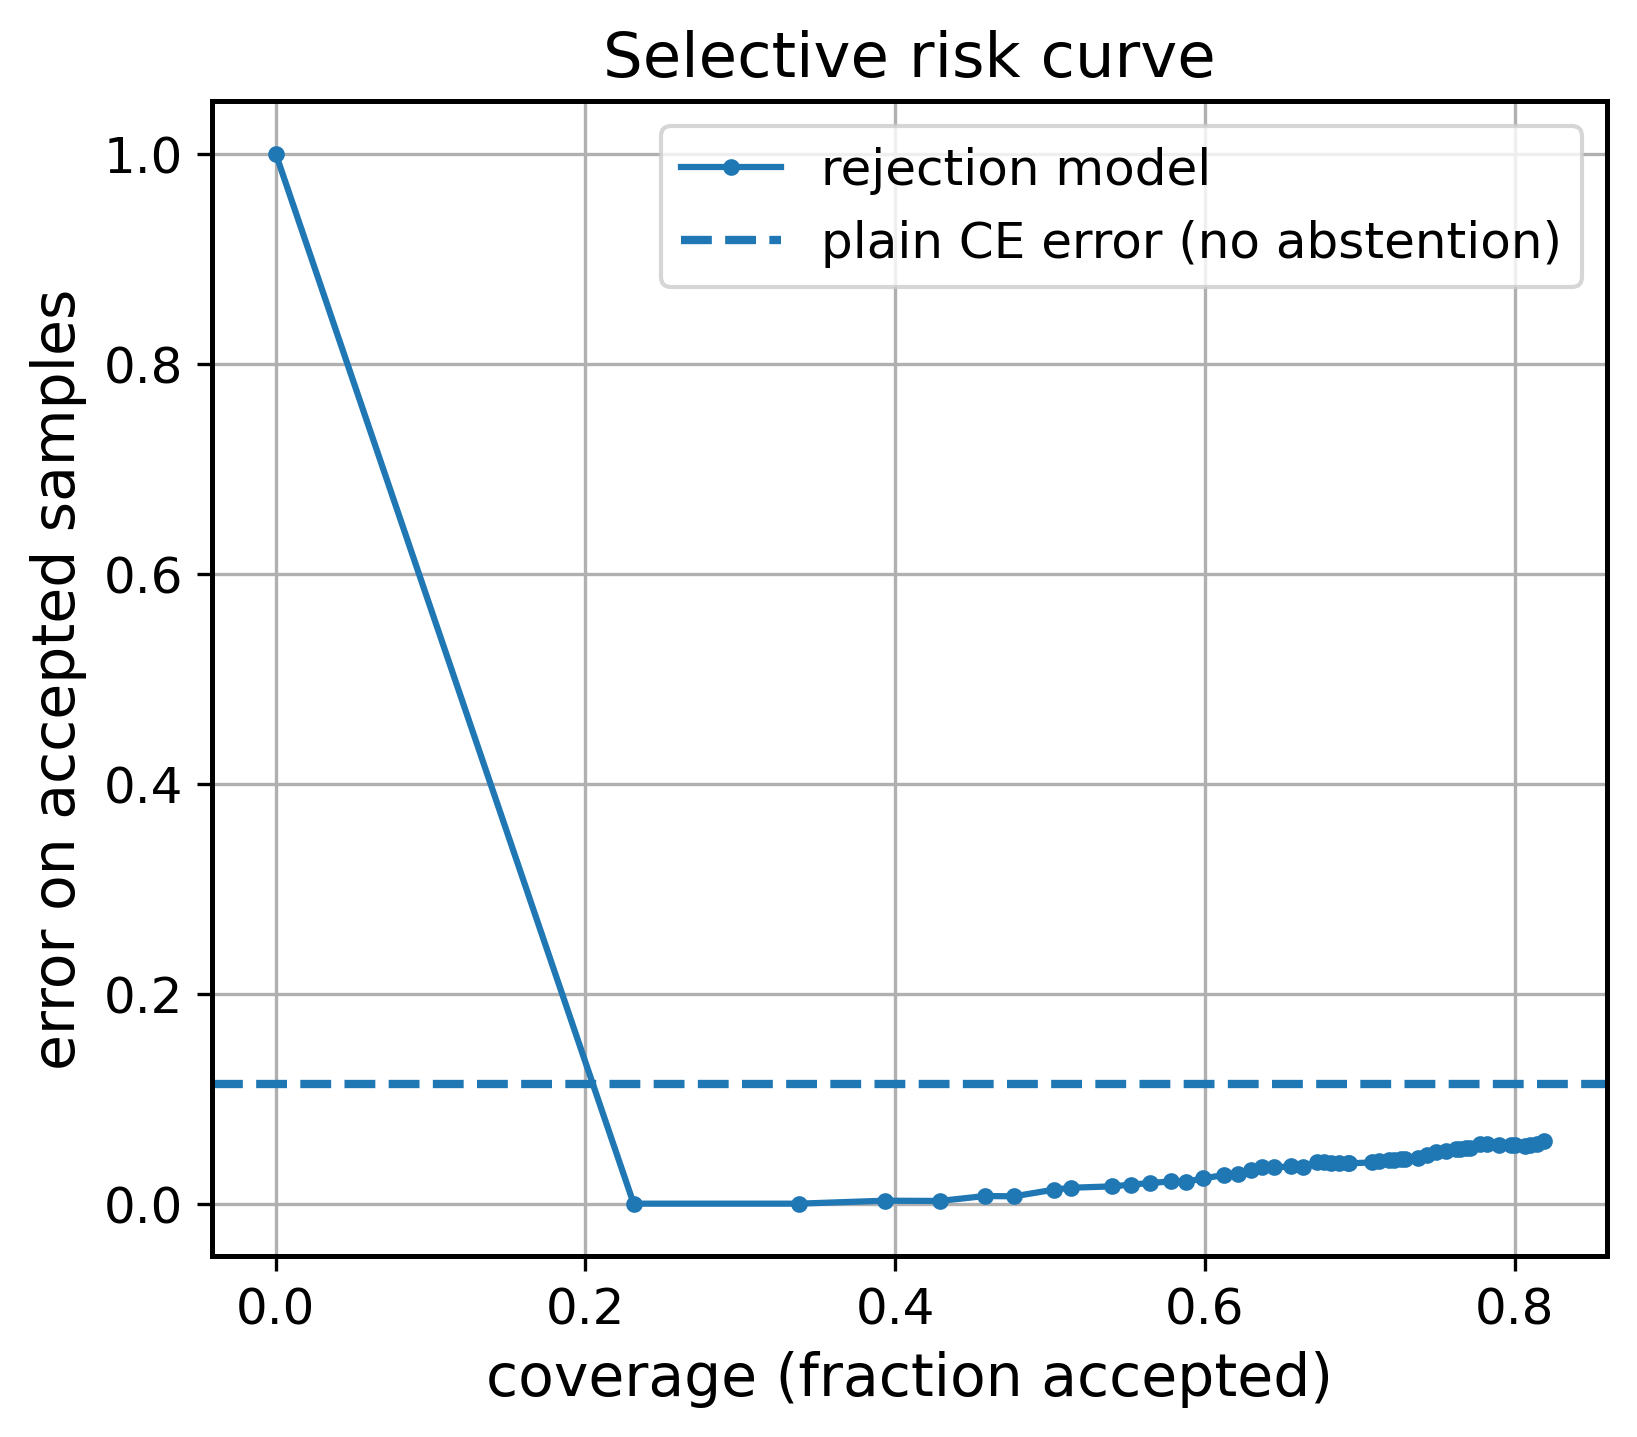

target coverage ~0.90 | actual coverage=0.819 | accepted error=0.060
target coverage ~0.80 | actual coverage=0.800 | accepted error=0.056
target coverage ~0.70 | actual coverage=0.693 | accepted error=0.038
target coverage ~0.60 | actual coverage=0.599 | accepted error=0.024


In [10]:
thresholds = np.linspace(0.00, 0.50, 51)
coverages = []
accepted_errors = []
accepted_accs = []
for th in thresholds:
    m = evaluate_rejection(rej_model, threshold=float(th))
    coverages.append(m['coverage'])
    accepted_errors.append(m['accepted_error'])
    accepted_accs.append(m['accepted_accuracy'])

baseline_error = ce_metrics['error']

fig, ax = plt.subplots()
ax.plot(coverages, accepted_errors, marker='o',
        markersize=3, linewidth=1.5, label='rejection model')
ax.axhline(baseline_error, linestyle='--',
           label='plain CE error (no abstention)')
ax.set_xlabel('coverage (fraction accepted)')
ax.set_ylabel('error on accepted samples')
ax.set_title('Selective risk curve')
ax.legend(loc='best')
plt.show()

for target_cov in [0.90, 0.80, 0.70, 0.60]:
    idx = int(np.argmin(np.abs(np.array(coverages) - target_cov)))
    print(
        f"target coverage ~{target_cov:.2f} | actual coverage={coverages[idx]:.3f} | "
        f"accepted error={accepted_errors[idx]:.3f}"
    )

Median top-1 minus top-2 margin (accepted): 0.965
Median top-1 minus top-2 margin (rejected): 0.181
Mean   top-1 minus top-2 margin (accepted): 0.893
Mean   top-1 minus top-2 margin (rejected): 0.201


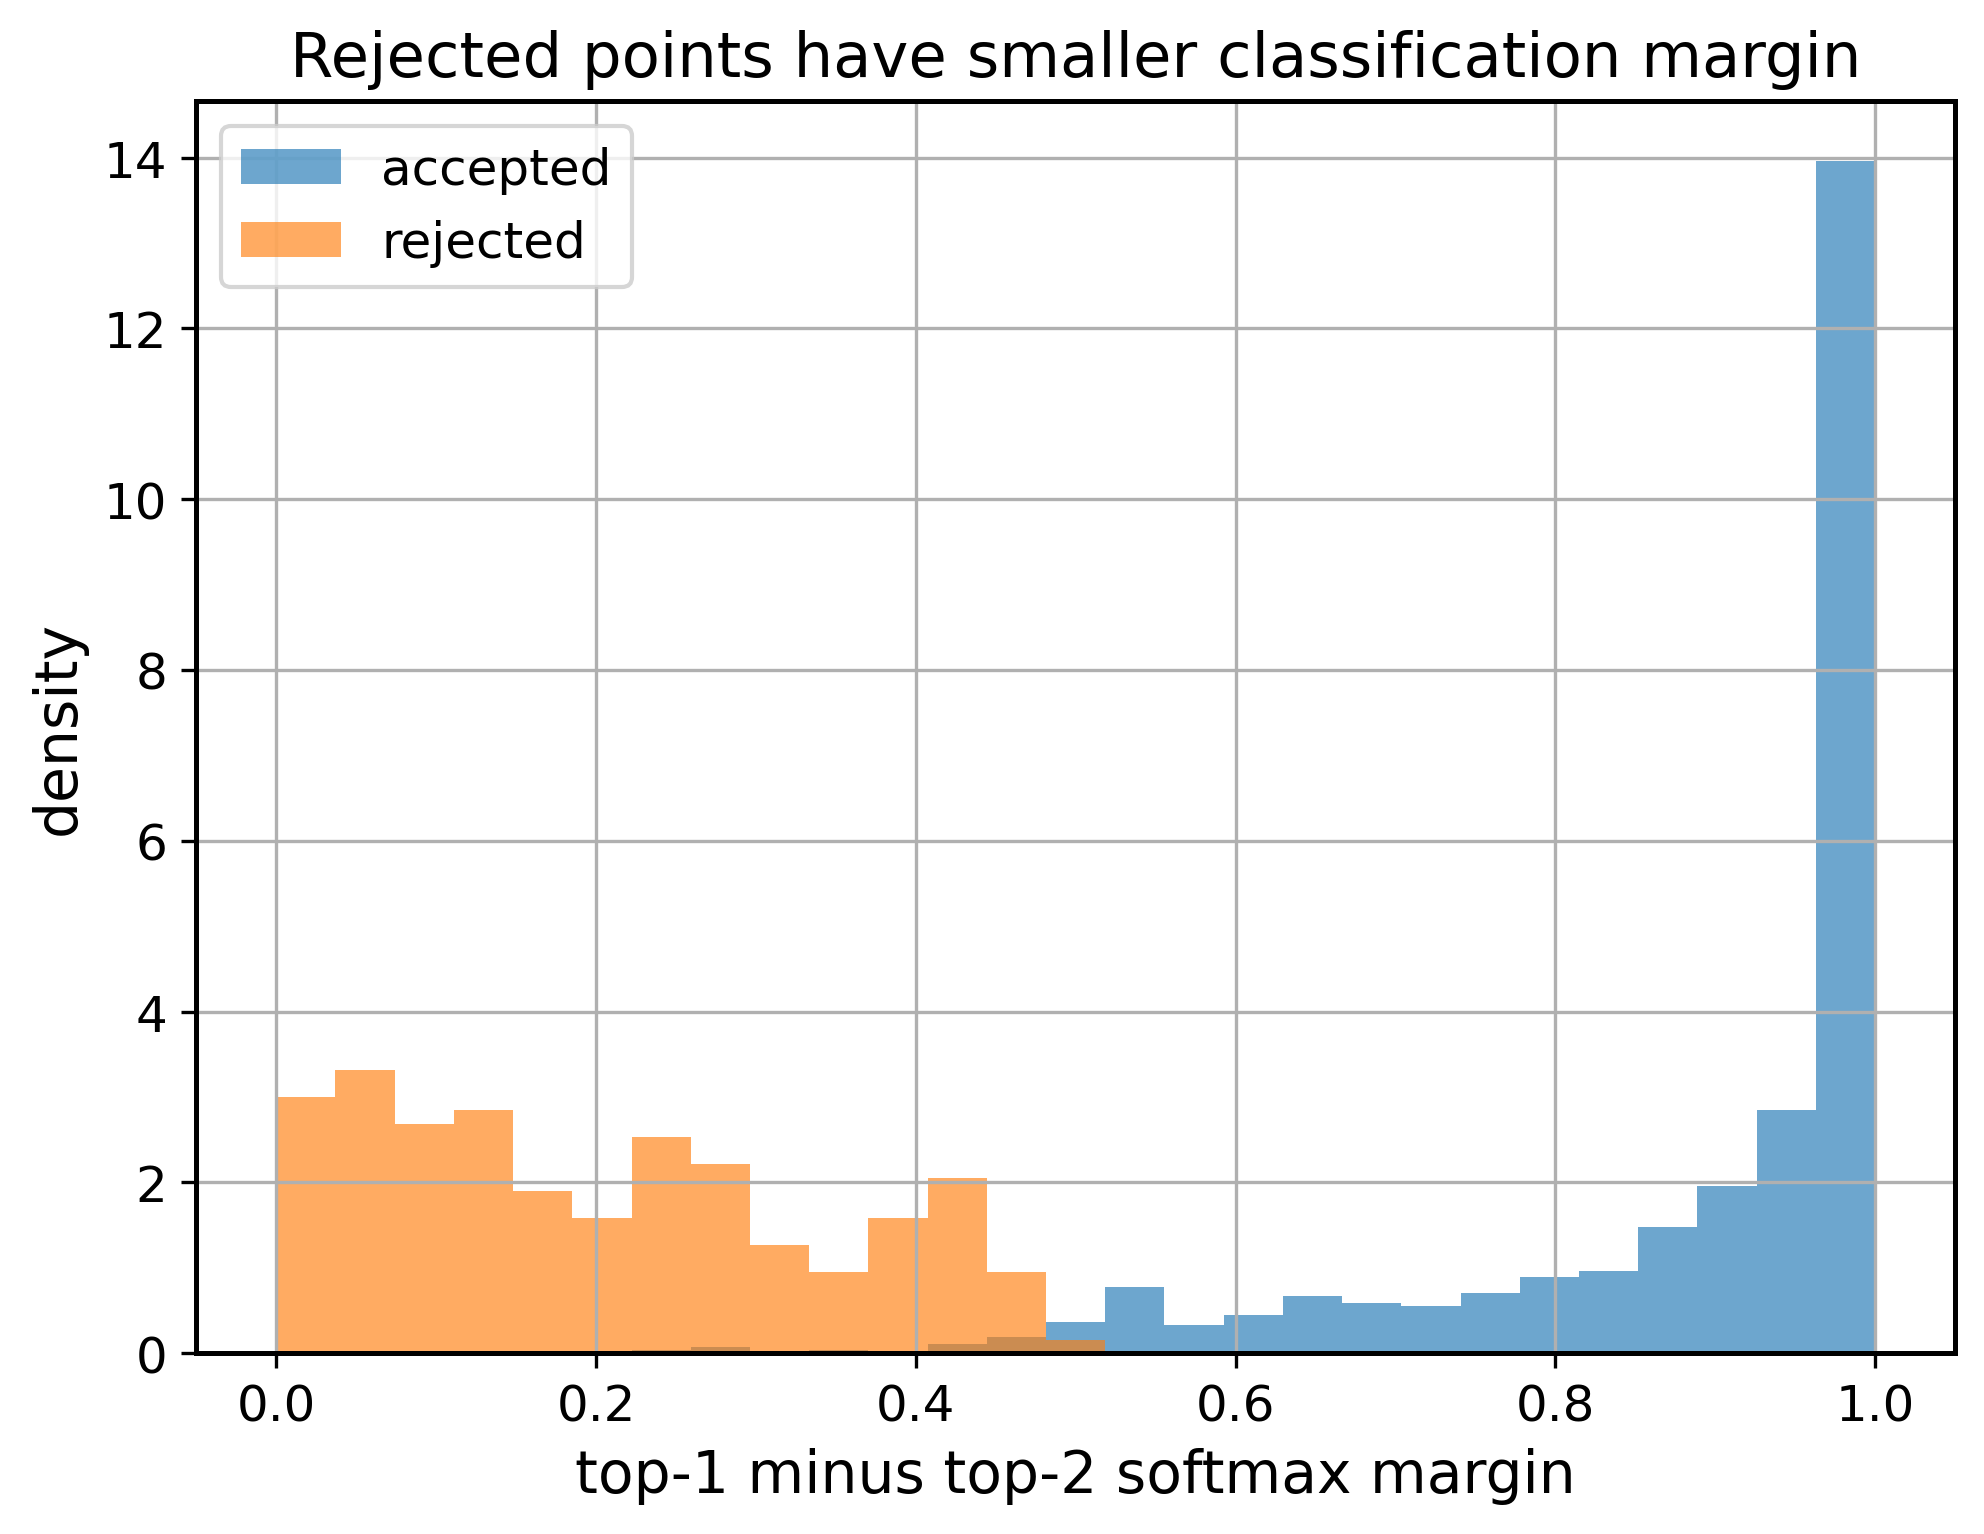

In [11]:
# using the classificatino margin as a proxy for confidence, i.e., the distance from the decision boundary, and comparing the margin for accepted vs rejected points

with torch.no_grad():
    logits = rej_model(X_test_t)
    probs = torch.softmax(logits, dim=1)

    class_probs = probs[:, :-1]
    top2 = torch.topk(class_probs, k=2, dim=1).values
    margin = (top2[:, 0] - top2[:, 1]).cpu().numpy()

accepted = rej_metrics_default["accepted"]
rejected = ~accepted

accepted_margin = margin[accepted]
rejected_margin = margin[rejected]

print(
    f"Median top-1 minus top-2 margin (accepted): {np.median(accepted_margin):.3f}")
print(
    f"Median top-1 minus top-2 margin (rejected): {np.median(rejected_margin):.3f}")
print(
    f"Mean   top-1 minus top-2 margin (accepted): {accepted_margin.mean():.3f}")
print(
    f"Mean   top-1 minus top-2 margin (rejected): {rejected_margin.mean():.3f}")

# fig, ax = plt.subplots(figsize=(7, 4))
fig, ax = plt.subplots(figsize=(6.5, 5), constrained_layout=True)
bins = np.linspace(0.0, max(margin.max(), 1e-6), 28)
ax.hist(accepted_margin, bins=bins, density=True, alpha=0.65, label="accepted")
ax.hist(rejected_margin, bins=bins, density=True, alpha=0.65, label="rejected")
ax.set_xlabel("top-1 minus top-2 softmax margin")
ax.set_ylabel("density")
ax.set_title("Rejected points have smaller classification margin")
ax.legend()
plt.show()